# (06) iP-VAE debug, etc.

project = ```iP-VAE```, host = ```mach```, device = ```cuda:1```

**Motivation**: <br>

First round of coding/debugging.

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
# from analysis.eval import sparse_score
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
from figures.analysis import plot_convergence
from figures.imgs import plot_weights


device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: mach

In [3]:
cm = 'bias-local_lr-global'
model_name = 'poisson_vH16_t-10×1_b-1_z-[512]_<grad|lin>'
fit_name = 'b200-ep300-lr(0.002)_beta(12:0x0.1)_temp(0.05:lin-0.5)_gr(200)_(2025_02_09,18:32)'
s = f"{model_name}/{cm}_{fit_name}"

tr, meta = load_model(s, lite=False, device=device)

100%|█████████████████████████████████| 10/10 [04:56<00:00, 29.62s/it]


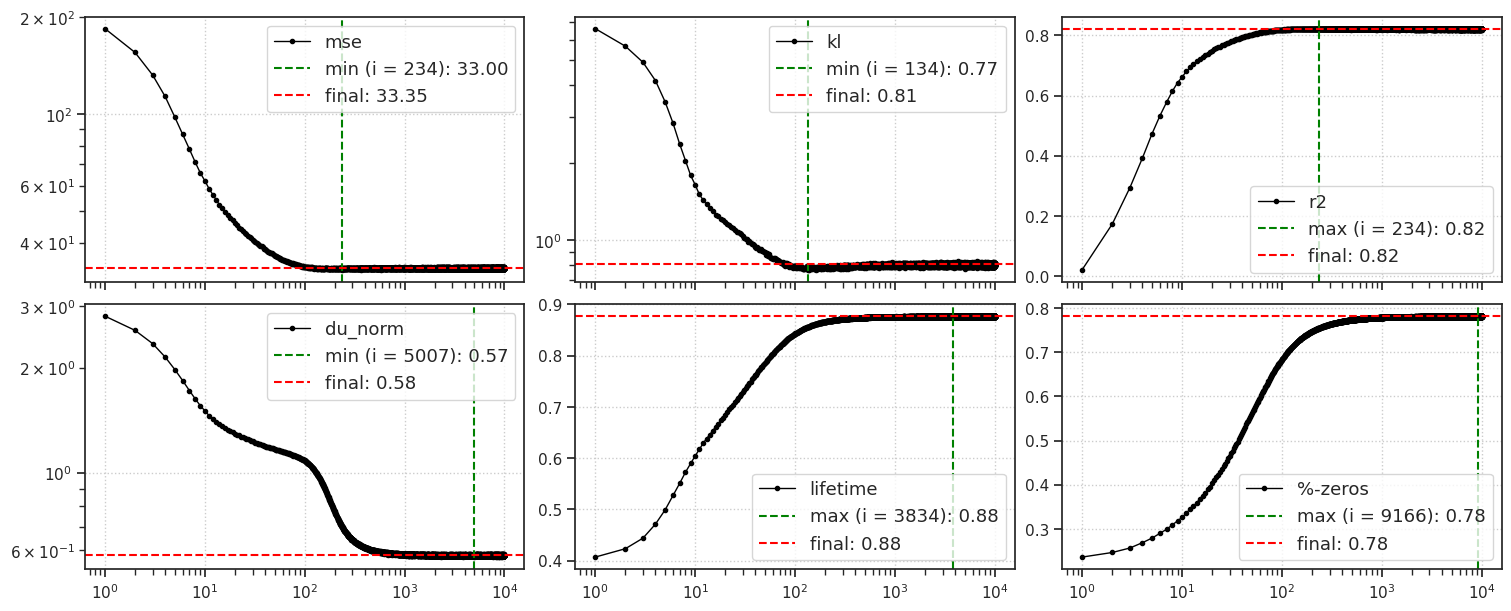

In [4]:
kws = dict(
    seq_total=10000,
    seq_batch_sz=1000,
    n_data_batches=10,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='k')

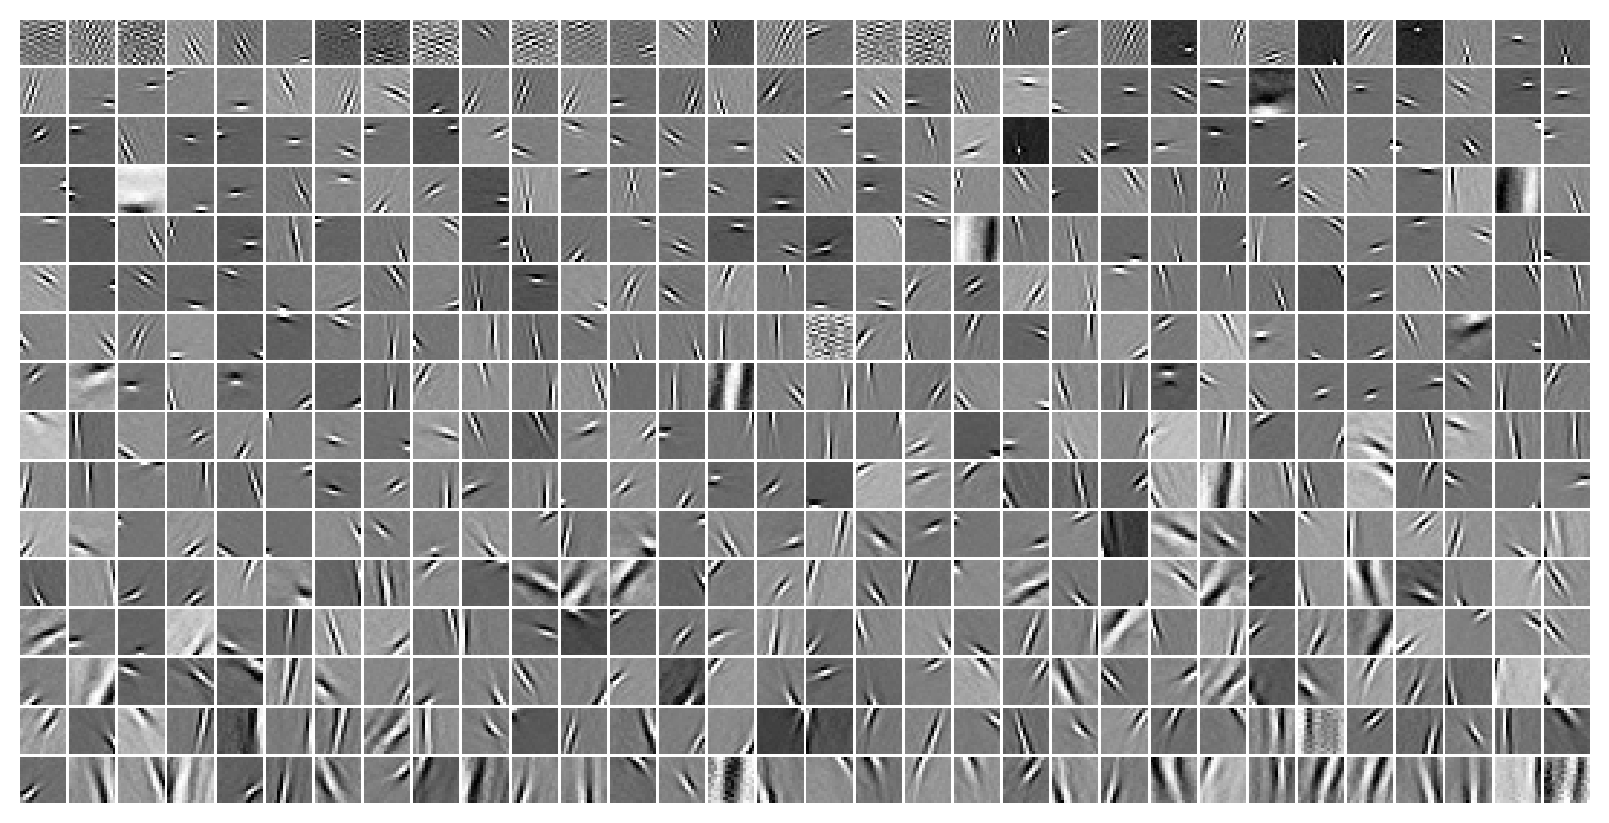

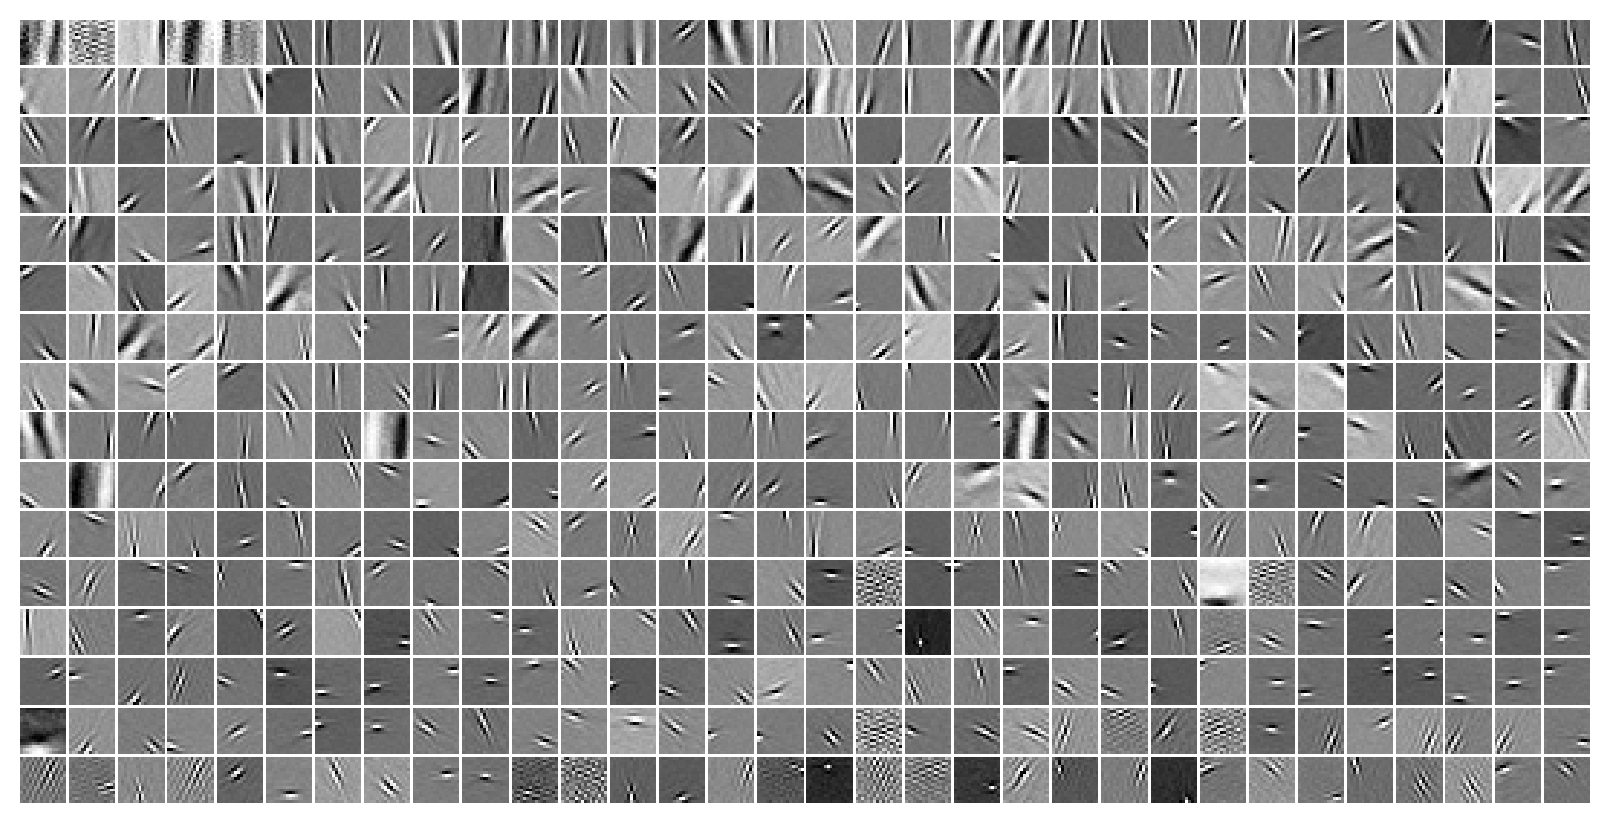

In [5]:
u0 = tonp(tr.model.layer.u_init.squeeze().exp())
bias = tonp(tr.model.layer.log_bias.squeeze().exp())

tr.model.show(order=np.argsort(u0));
tr.model.show(order=np.argsort(bias));

In [6]:
sp_stats.pearsonr(u0, bias)

PearsonRResult(statistic=-0.8827145148681286, pvalue=2.1340781180023318e-169)

In [7]:
print(vars(tr.model.cfg))

{
    'prior_log_dist': 'uniform',
    'clamp_prior': -4,
    'seq_len': 10,
    'n_iters': 1,
    'beta_inner': 1.0,
    'n_latents': [512],
    'inf_type': 'grad',
    'dec_type': 'lin',
    'dataset': 'vH16',
    'feeder': 'stationary',
    'feeder_cfg': {},
    'input_sz': (1, 16, 16),
    'shape': (-1, 1, 16, 16),
    'clamp_u': 8.0,
    'clamp_du': 10.0,
    'init_dist': 'normal',
    'init_scale': 0.01,
    'activation_fn': 'swish',
    'fit_prior': True,
    'stochastic': True,
    'track_stats': True,
    'seed': 0,
    'base_dir': '/home/hadi/Projects/PoissonVAE',
    'data_dir': '/home/hadi/Datasets',
    'runs_dir': '/home/hadi/Projects/PoissonVAE/runs/poisson_vH16_t-10_z-[512]_<grad|lin>',
    'mods_dir': '/home/hadi/Projects/PoissonVAE/models/poisson_vH16_t-10_z-[512]_<grad|lin>',
    'results_dir': '/home/hadi/Projects/PoissonVAE/results'
}

In [8]:
print(tr.model.cfg.name())

poisson_vH16_t-10_z-[512]_<grad|lin>

100%|█████████████████████████████████| 10/10 [04:46<00:00, 28.67s/it]


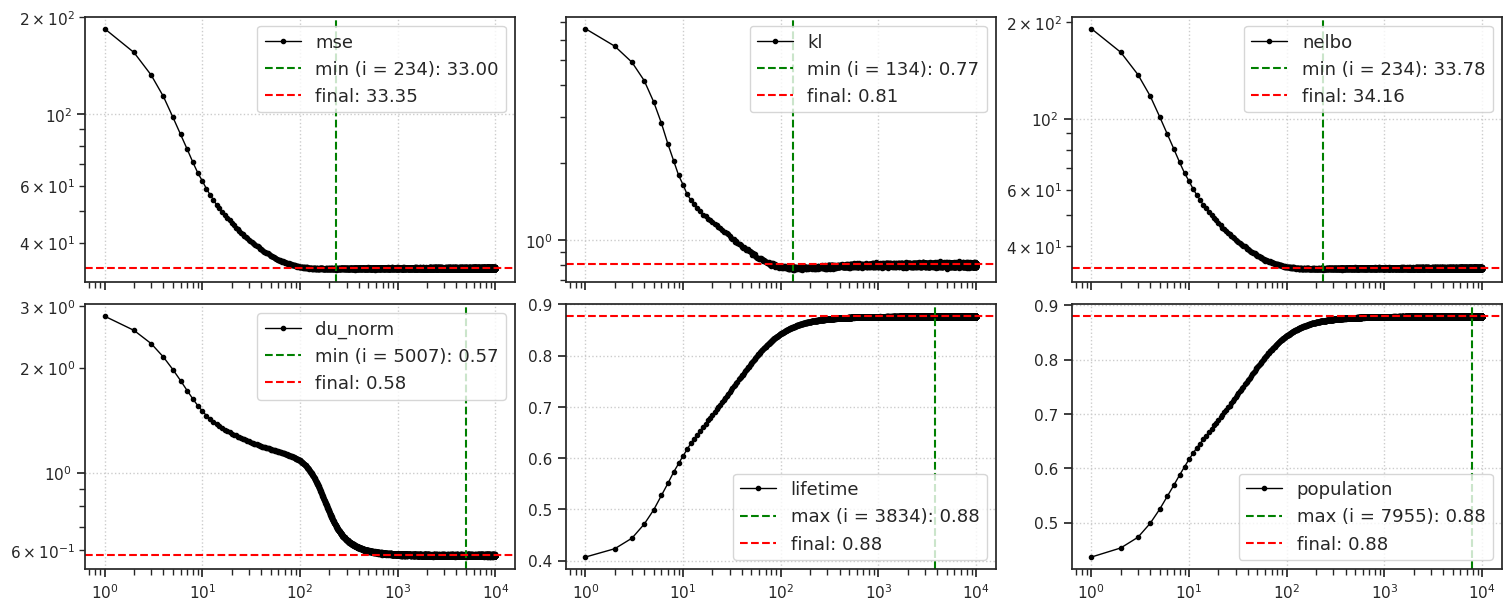

In [8]:
"""kws = dict(
    seq_total=10000,
    seq_batch_sz=1000,
    n_data_batches=10,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='k')"""

## Continuous Poisson?

In [3]:
from main.distributions import Poisson

In [77]:
bin_width = 0.01
num = 1100

z_start = bin_width / 2
z_end = z_start + num * bin_width
zs = torch.linspace(z_start, z_end, num + 1)

In [78]:
lam = torch.tensor([3.5])

pois_continuous = zs.pow(lam.item()) * torch.exp(-lam) / torch.exp(torch.lgamma(zs + 1))
pois_continuous /= torch.sum(pois_continuous)

pois_continuous /= bin_width

In [79]:
pois = Poisson(log_rate=torch.log(lam), temp=0.0)
samples = []
for _ in range(10000):
    z = pois.rsample()
    samples.append(z.item())

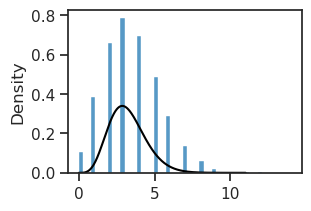

In [95]:
fig, ax = create_figure()
ax.plot(tonp(zs), tonp(pois_continuous), color='k')
sns.histplot(samples, ax=ax, stat='density')
plt.show()

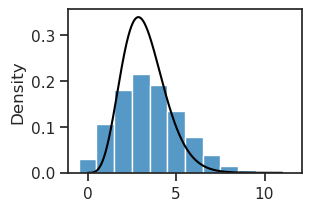

In [105]:
fig, ax = create_figure()
ax.plot(tonp(zs), tonp(pois_continuous), color='k')
sns.histplot(samples, ax=ax, stat='density', bins=np.linspace(0, 12, 13) - 0.5)
plt.show()

In [4]:
log_rate = nn.Parameter(torch.tensor(
    np.linspace(-1, 4, 100),
))

dz_dr_all = {}
for temp in [0.01, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0]:
    p = Poisson(log_rate=log_rate, temp=temp)
    z = p.rsample()

    dz_dr = torch.autograd.grad(z.sum(), p.rate, create_graph=True)[0]
    dz_dr_all[temp] = dz_dr

<Axes: ylabel='Count'>

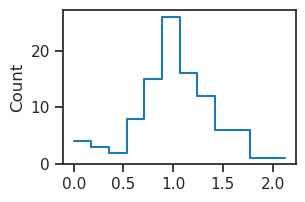

In [13]:
histplot(dz_dr_all[0.5])

In [14]:
dz_dr_all[0.5].mean()

tensor(1.0104, dtype=torch.float64, grad_fn=<MeanBackward0>)

In [7]:

print(dz_dr_np)

tensor([2.2377, 0.7221, 1.3924, 1.0421, 3.8542, 2.5781, 0.9173, 1.0569, 0.1628,
        3.4658, 0.3126, 1.0930, 2.0698, 2.0899, 1.6007, 1.1405, 1.0662, 0.9232,
        0.9095, 0.5675, 1.8489, 1.8694, 1.1369, 1.5367, 2.0670, 1.3610, 0.8731,
        1.8879, 1.4021, 0.8126, 1.4259, 0.7895, 1.5156, 1.5797, 0.8429, 1.1421,
        1.3169, 1.3766, 0.9821, 1.8769, 1.3522, 1.0582, 1.4111, 0.8201, 1.4575,
        1.8411, 1.6200, 1.2503, 1.5741, 1.4526, 1.3570, 1.6084, 1.2991, 1.4267,
        0.8862, 1.4322, 1.2716, 0.9015, 1.4293, 0.9720, 1.3432, 1.3777, 1.3831,
        1.3728, 1.5571, 1.4571, 1.8316, 1.3735, 1.3450, 1.3144, 0.9960, 1.3617,
        1.3391, 1.3023, 1.0688, 1.2274, 1.1519, 1.2048, 1.2271, 1.1219, 1.1469,
        1.2055, 1.1647, 1.0279, 1.0603, 0.9363, 0.8748, 0.7997, 0.8274, 0.7202,
        0.7628, 0.6573, 0.6554, 0.6054, 0.5042, 0.5536, 0.5034, 0.4386, 0.3844,
        0.3162], dtype=torch.float64)

<Axes: ylabel='Count'>

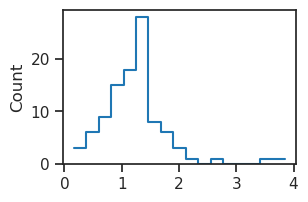

In [8]:
histplot(dz_dr)

In [7]:
p.rate = p.rate.detach().requires_grad_()

In [16]:
i = 0
torch.autograd.grad(z[i].sum(), p.rate, create_graph=True)[0]

tensor([1.1158, 0.0000, 0.0000], grad_fn=<ViewBackward0>)

## Trainer

In [3]:
model_type = 'poisson'

cfg_vae, cfg_tr = default_configs('vH16', model_type, 'grad|lin')
cfg_vae['seq_len'] = 8
cfg_vae['n_iters'] = 1

cfg_vae['track_stats'] = True

# set betas
cfg_vae['beta_inner'] = 8.0
cfg_tr['kl_beta'] = 8.0

print(f"VAE:\n{cfg_vae}\n\nTrainer:\n{cfg_tr}")

VAE:
{'dataset': 'vH16', 'n_latents': 512, 'clamp_prior': -4, 'clamp_du': 10.0, 'clamp_u': 8.0, 'inf_type': 'grad', 
'dec_type': 'lin', 'init_dist': 'normal', 'init_scale': 0.0001, 'seq_len': 8, 'n_iters': 1, 'track_stats': True, 
'beta_inner': 8.0}

Trainer:
{'batch_size': 200, 'epochs': 300, 'optimizer_kws': {'weight_decay': 0.0}, 'grad_clip': 200, 'kl_beta': 8.0}

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IPVAE    |  131.8 K   |
|     ———     |    ———     |
|    layer    |  131.8 K   |
+-------------+------------+

poisson_vH16_t-8×1_b-8_z-[512]_<grad|lin>
b200-ep300-lr(0.002)_beta(8:0x0.1)_temp(0.05:lin-0.5)_gr(200)_(2025_02_08,15:11)

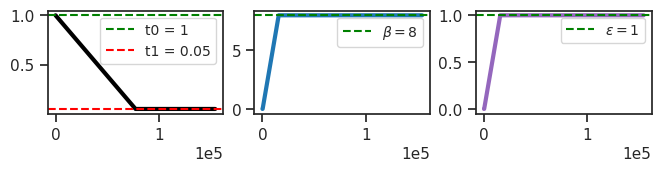

In [4]:
mod = MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae))

# mod.layer.log_scale.requires_grad = False
# mod.layer.log_bias.requires_grad = False
mod.layer.log_lr.requires_grad = False
mod.layer.v_init.requires_grad = False

tr = Trainer(mod, ConfigTrain(**cfg_tr), device=device)

mod.print()
print(f"{mod.cfg.name()}\n{tr.cfg.name()}_({mod.timestamp})\n")
tr.show_schedules()

In [5]:
feeder = tr.get_feeder()

In [6]:
tr.model.reset_state(len(feeder.x))
tr.model.layer.initialize_inference()

In [7]:
posterior = tr.model.layer.get_dist()

In [8]:
posterior.rate

tensor([[0.0089, 0.0043, 0.0027,  ..., 0.0169, 0.0083, 0.0069],
        [0.0089, 0.0043, 0.0027,  ..., 0.0169, 0.0083, 0.0069],
        [0.0089, 0.0043, 0.0027,  ..., 0.0169, 0.0083, 0.0069],
        ...,
        [0.0089, 0.0043, 0.0027,  ..., 0.0169, 0.0083, 0.0069],
        [0.0089, 0.0043, 0.0027,  ..., 0.0169, 0.0083, 0.0069],
        [0.0089, 0.0043, 0.0027,  ..., 0.0169, 0.0083, 0.0069]],
       device='cuda:1', grad_fn=<AddBackward0>)

In [9]:
z = posterior.rsample()

In [10]:
dz_dr = torch.autograd.grad(z.sum(), posterior.rate, create_graph=True)[0]

In [11]:
dz_dr.shape

torch.Size([200, 512])

In [16]:
aaa = tonp(dz_dr)

<Axes: ylabel='Count'>

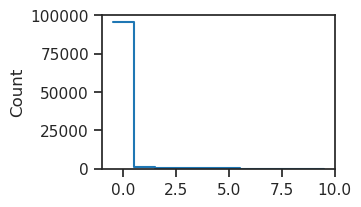

In [21]:
histplot(aaa.ravel(), bins=np.linspace(0, 10, 11) - 0.5)

In [23]:
np.round(aaa, 2)

array([[ 0.  ,  0.  ,  0.  , ...,  0.  ,  0.  ,  0.  ],
       [ 0.  ,  0.  ,  0.  , ...,  0.  ,  0.  , 53.81],
       [ 0.  ,  0.  ,  0.  , ..., 32.45,  0.  ,  0.  ],
       ...,
       [ 0.  ,  0.  ,  0.  , ...,  0.  ,  0.  ,  0.  ],
       [ 0.  ,  0.  ,  0.  , ...,  0.  ,  0.  ,  0.  ],
       [ 0.  ,  0.  ,  0.  , ..., 14.28,  0.  ,  0.  ]], dtype=float32)

In [5]:
cm = 'langevin+log_bias-log_lr'
tr.train(fit_name=f"{cm}_{tr.cfg.name()}")

epoch # 300, avg loss: 338.008919: 100%|████| 300/300 [1:42:58<00:00, 20.60s/it]


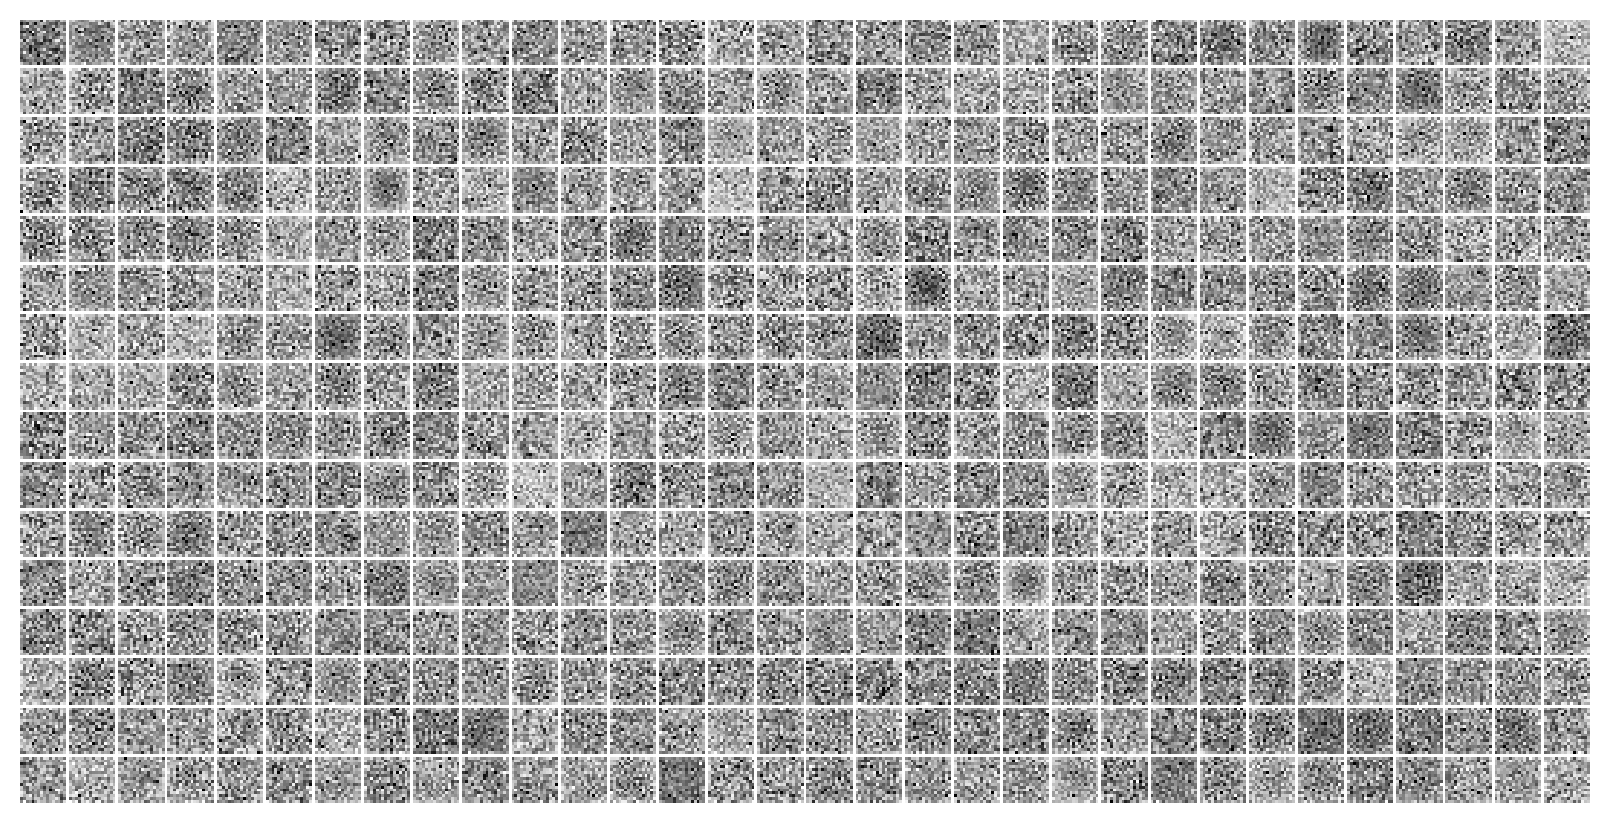

In [7]:
tr.model.show();

In [7]:
data, loss, etc = tr.validate()

In [10]:
u = tonp(tr.model.layer.u)
v = tonp(tr.model.layer.v)

u.shape, v.shape

((11, 512), (11, 512))

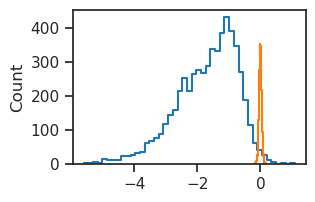

In [11]:
histplot(u.ravel());
histplot(v.ravel());

In [59]:
bias = tonp(tr.model.layer.bias.squeeze())
log_gain = tonp(tr.model.layer.log_gain.squeeze())
log_scale = tonp(tr.model.layer.log_scale.squeeze())

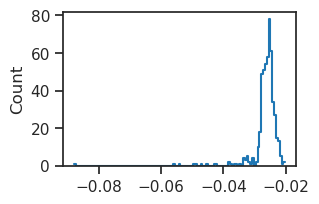

In [60]:
histplot(bias);

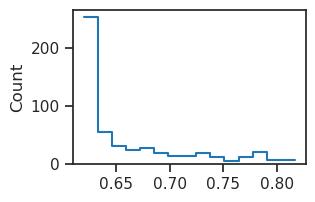

In [61]:
histplot(log_gain);

<Axes: ylabel='Count'>

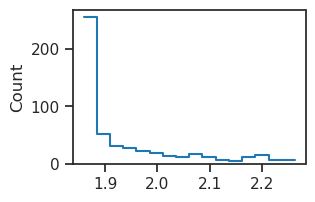

In [63]:
histplot(np.exp(log_gain))

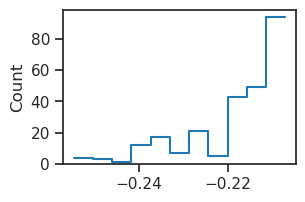

In [62]:
histplot(log_scale);

In [5]:
feeder = tr.get_feeder(next(iter(tr.dl_trn))[0])

In [6]:
output = tr.model(feeder, return_extras=True)
print(output)

Keys: ['loss_kl', 'loss_recon', 'posterior', 'u', 'v', 'a', 'recon', 'samples', 'conditional']

In [7]:
output = output.stack()
list(output)

['loss_kl',
 'loss_recon',
 'posterior',
 'u',
 'v',
 'a',
 'recon',
 'samples',
 'conditional']

In [13]:
data, loss, etc = tr.validate()

In [14]:
list(etc)

['u', 'v', 'a']

In [16]:
etc['a'].shape

(25811, 8, 512)

In [5]:
print(tr.model)

IPVAE(
  (layer): PoissonLayer(input_dim=256,latent_dim=512, temp=1, beta=1)
)

In [6]:
print(tr.model.layer)

PoissonLayer(input_dim=256,latent_dim=512, temp=1, beta=1)

In [7]:
print_num_params(tr.model.layer)

+--------------+------------+
| Module Name  | Num Params |
+--------------+------------+
| PoissonLayer |  133.4 K   |
|     ———      |    ———     |
|     phi      |  131.1 K   |
+--------------+------------+

In [8]:
x, *_ = next(iter(tr.dl_trn))
feeder = tr.get_feeder(x)

In [9]:
output = tr.model(feeder, return_extras=True)

In [11]:
output = output.stack()

In [12]:
list(output)

['loss_kl',
 'loss_recon',
 'posterior',
 'u',
 'v',
 'a',
 'recon',
 'samples',
 'conditional']

In [15]:
output['samples'].shape

torch.Size([200, 16, 512])

In [10]:
print(output)

Keys: ['loss_kl', 'loss_recon', 'posterior', 'u', 'v', 'a', 'recon', 'samples', 'conditional']

In [9]:
x = feeder[0]
x.shape

torch.Size([200, 256])

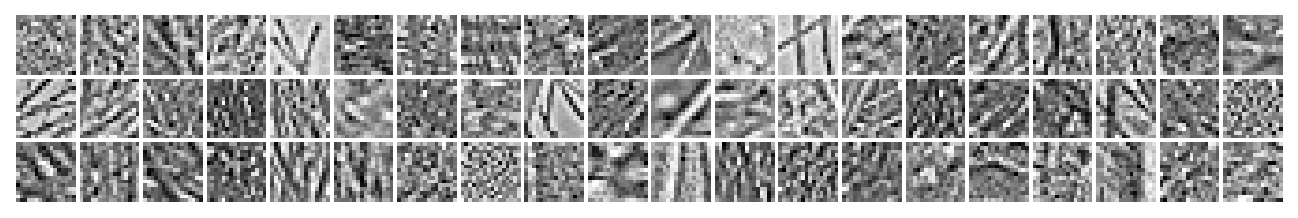

In [10]:
_ = plot_weights(x.reshape(tr.model.cfg.shape)[:60, 0], nrows=3)

In [11]:
tr.model.reset_state(len(x))

In [12]:
traj_u, traj_v, traj_a = tr.model.layer(x)

In [13]:
tr.model.layer.u

tensor([[-4.7256, -5.4607, -5.9176,  ..., -4.0803, -4.7904, -4.9692],
        [-4.7259, -5.4586, -5.9182,  ..., -4.0788, -4.7875, -4.9709],
        [-4.7286, -5.4577, -5.9214,  ..., -4.0802, -4.7909, -4.9709],
        ...,
        [-4.7249, -5.4586, -5.9172,  ..., -4.0760, -4.7914, -4.9698],
        [-4.7271, -5.4576, -5.9193,  ..., -4.0824, -4.7940, -4.9723],
        [-4.7261, -5.4574, -5.9174,  ..., -4.0816, -4.7952, -4.9720]],
       device='cuda:1', grad_fn=<RsubBackward1>)

In [14]:
tr.model.layer.u_prior

tensor([[-4.7261, -5.4604, -5.9181,  ..., -4.0787, -4.7923, -4.9697],
        [-4.7261, -5.4604, -5.9181,  ..., -4.0787, -4.7923, -4.9697],
        [-4.7261, -5.4604, -5.9181,  ..., -4.0787, -4.7923, -4.9697],
        ...,
        [-4.7261, -5.4604, -5.9181,  ..., -4.0787, -4.7923, -4.9697],
        [-4.7261, -5.4604, -5.9181,  ..., -4.0787, -4.7923, -4.9697],
        [-4.7261, -5.4604, -5.9181,  ..., -4.0787, -4.7923, -4.9697]],
       device='cuda:1', grad_fn=<ExpandBackward0>)